In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from os.path import isfile, join
import pylab as plt
from glob import glob
import subprocess
import re
import math

import geopandas
from matplotlib_scalebar.scalebar import ScaleBar

from shapely import wkt

import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [91]:
rawDataDir = "/Users/swise/Projects/hitomi/data/OkazakiABM/"#"/Users/swise/workspace/takamatsu/data/okazakiDemo/"
procDataDir = "/Users/swise/Projects/hitomi/data/transit/okazakiDemo/"

waterFloodedFile = rawDataDir + "03_inundation/waterBaselayer.shp"
roadsFile = rawDataDir + "03_inundation/roads_with_inundation_16hagibis.shp"
shelterFile = rawDataDir + "01_Shelter_OkazakiOpenData/sheltersWithParking.shp"

roads = geopandas.read_file(roadsFile)
inundated = roads[roads["A31b_201"] > .1]
water = geopandas.read_file(waterFloodedFile)
shelters = geopandas.read_file(shelterFile)

In [89]:
inundated.head()

,full_id,highway,lanes,oneway,layer,index_righ,A31b_201,geometry
0,w128708856,primary,2,0,1,1073684.0,10.880656,"LINESTRING (693353.702 3867127.322, 693766.434..."
1,w47075195,primary,0,0,0,950996.0,10.771623,"LINESTRING (702277.190 3881664.892, 702248.898..."
2,w128775855,secondary,0,0,1,1094669.0,10.124983,"LINESTRING (692300.634 3863486.895, 691767.099..."
3,w128708890,primary,4,0,1,1056865.0,10.115600,"LINESTRING (695742.566 3868015.603, 695403.316..."
4,w696156288,primary,0,yes,1,1047750.0,9.699626,"LINESTRING (695665.221 3873326.515, 696047.571..."


In [85]:
# read in the list of files from the directory
workingDir = procDataDir
files = os.listdir(workingDir)
holder = {} # set up the holder
f = files[0]

In [86]:
# helper function
def extractEvacTime(s):
    bits = s.split(',')
    record = {}
    for b in bits:
        try:
            k,v = b.split(':')
            if k[0] not in record:
                record[k] = float(v)
        except:
            pass

    if "START_EVACUATING" in record:
        startTime = record["START_EVACUATING"]
    else:
        startTime = record["START"]
    finishTime = 1440
    if "FINISH_EVAC" in record:
        finishTime = record["FINISH_EVAC"]
    elif "TRAPPED" in record:
        finishTime = record["TRAPPED"]
        
    return finishTime - startTime

/Users/swise/opt/anaconda3/envs/takamatsu/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:395: MatplotlibDeprecationWarning: 
The is_last_row function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_row() instead.
  if ax.is_last_row():
/Users/swise/opt/anaconda3/envs/takamatsu/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:395: MatplotlibDeprecationWarning: 
The is_last_row function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_row() instead.
  if ax.is_last_row():
/Users/swise/opt/anaconda3/envs/takamatsu/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:395: MatplotlibDeprecationWarning: 
The is_last_row function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_last_row() instead.
  if ax.is_last_row():
/Users/swise/opt/anaconda3/envs/takamatsu/lib/

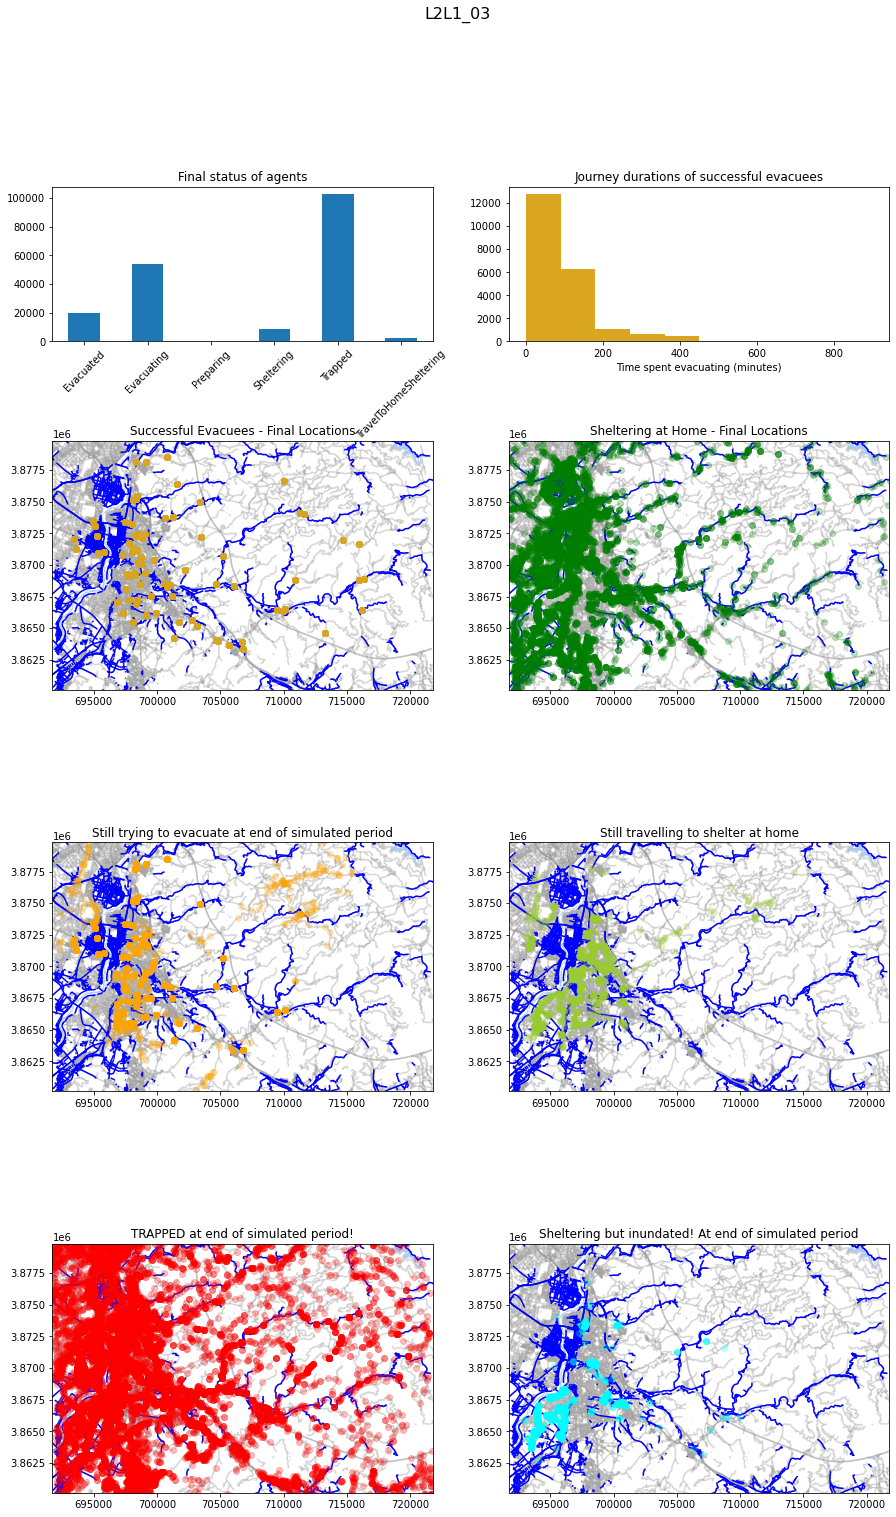

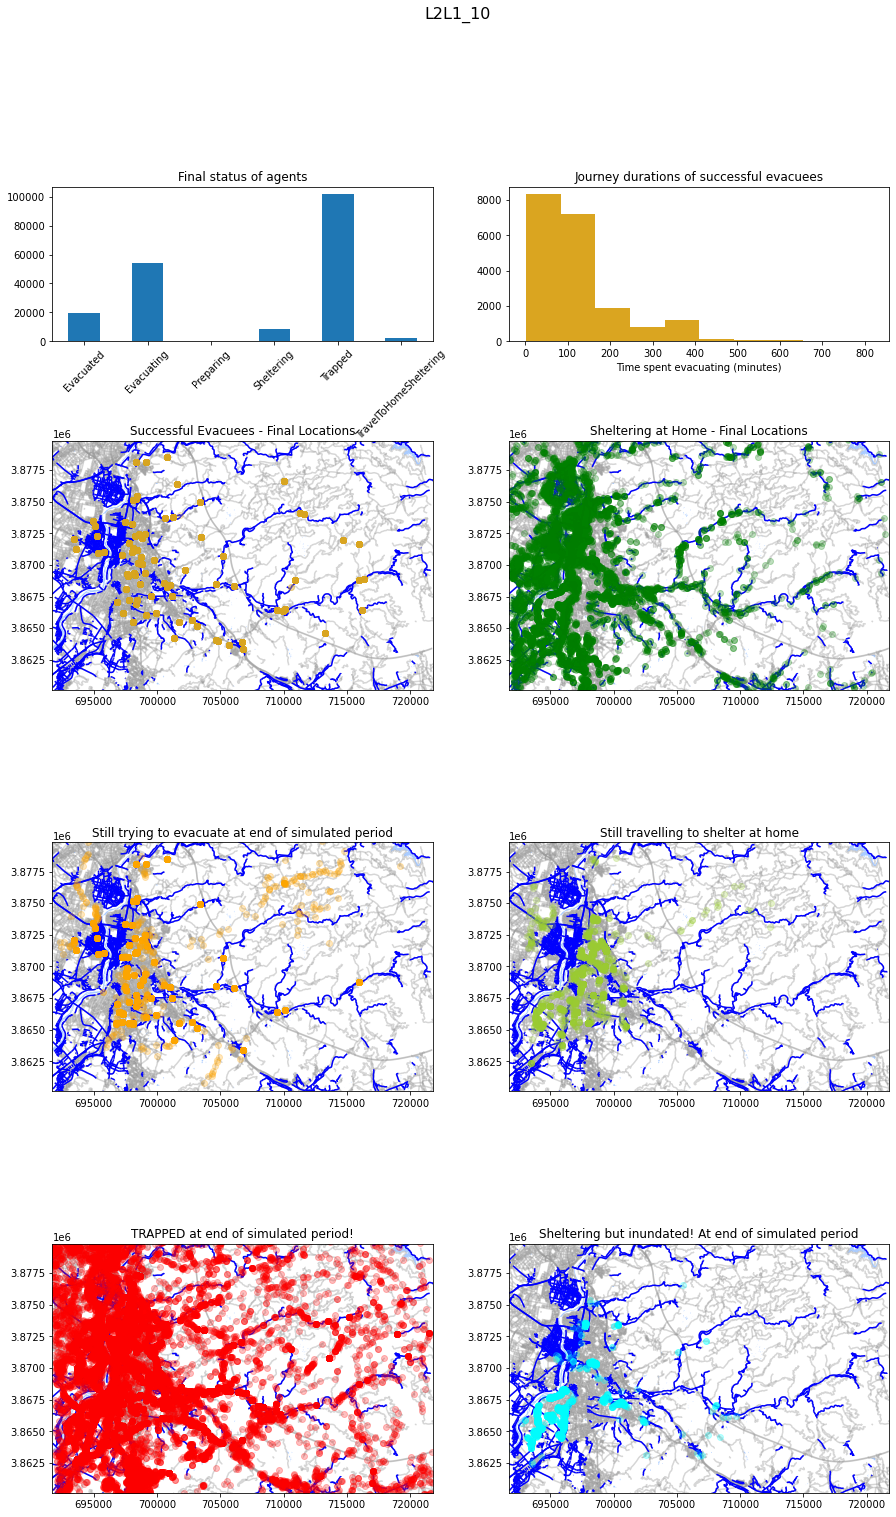

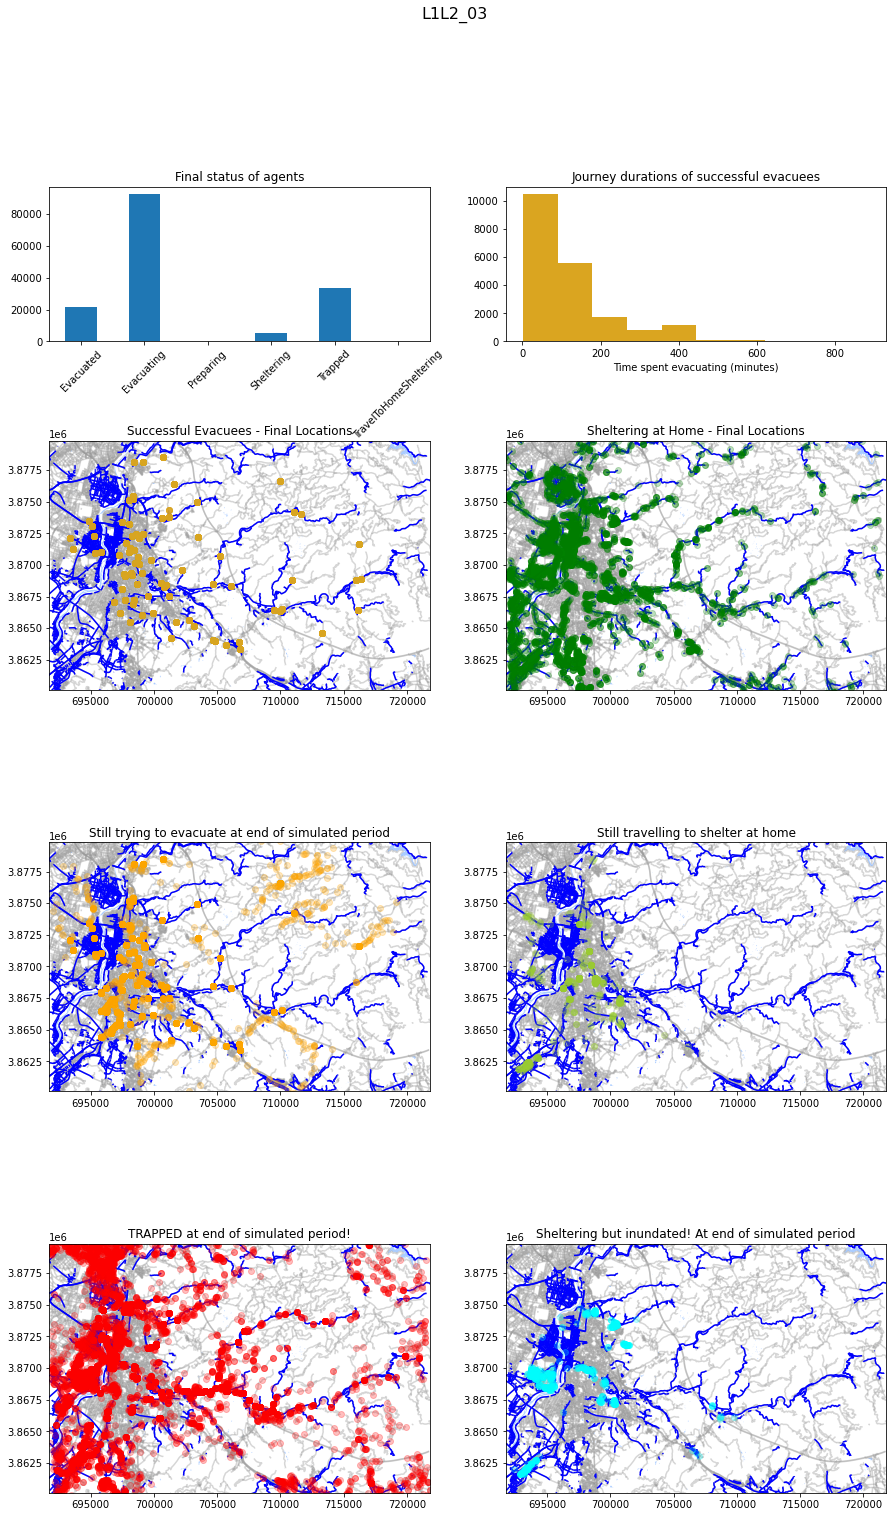

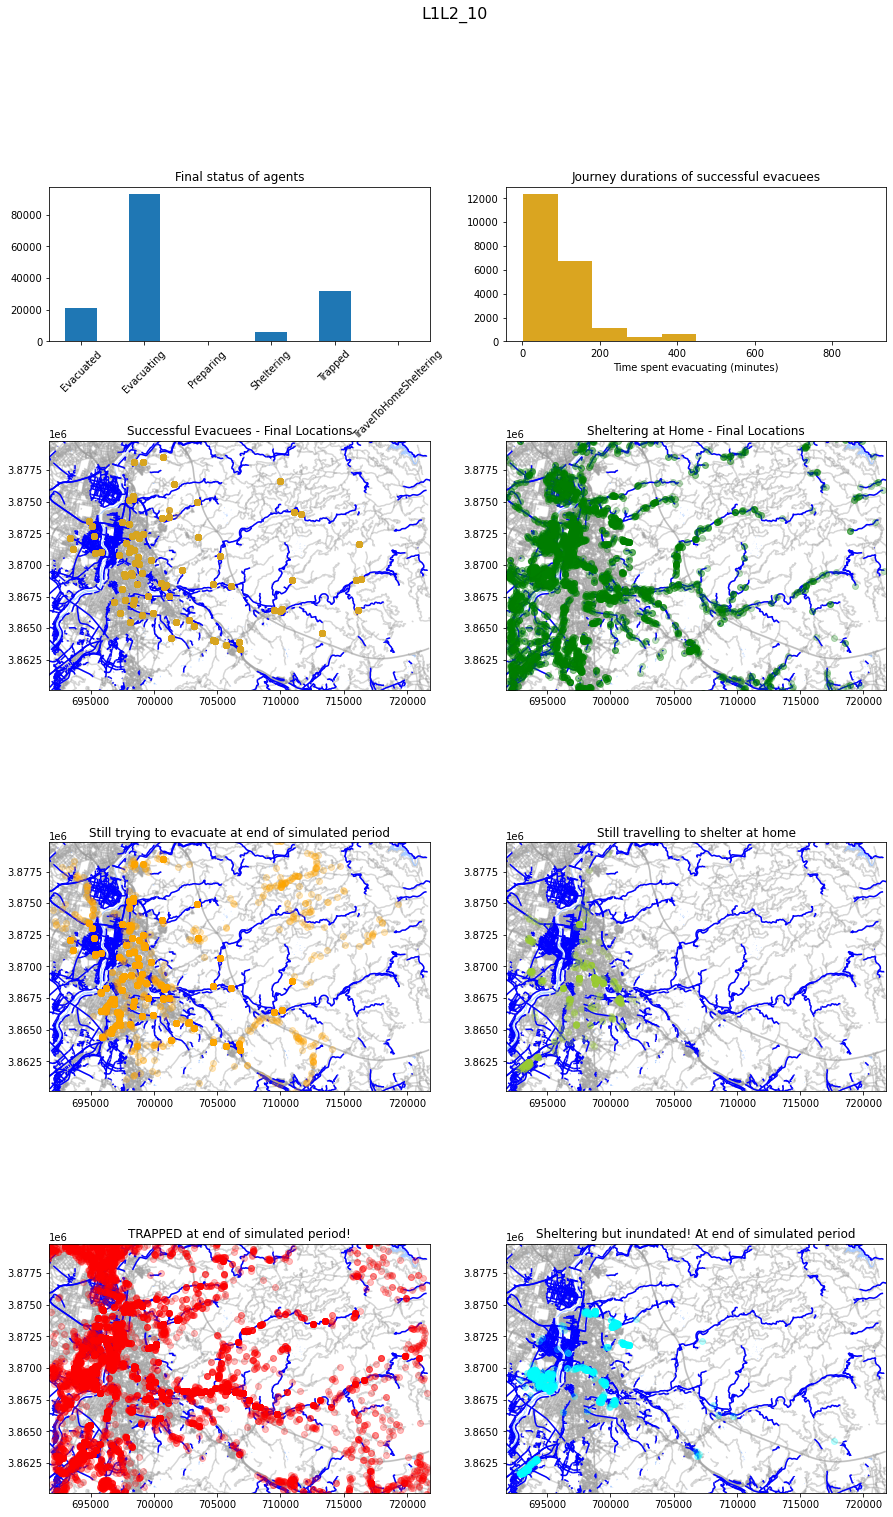

In [92]:
successfulEvacuees = {}
shelteringAtHome = {}
trapped = {}
incomplete = {}

# a map for each
# journey distribution time

xcolname = 'x_loc'
ycolname = 'y_loc'



# shelter demand, capacity over time

# extract them
for f in files:
    
    if f.startswith("."):
        continue    
    elif "SHELTERS" in f:
        continue
    elif "heatmap" in f:
        continue
        
    scenario = f[:f.rfind("_")]
    
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file


    fig = plt.figure(figsize=(15,25))

    totalSize = (7, 2)
    
    ax1 = plt.subplot2grid(totalSize, (0, 0))
    ax2 = plt.subplot2grid(totalSize, (0, 1))#, colspan=2)
    ax3 = plt.subplot2grid(totalSize, (1, 0), rowspan=2)#, colspan=2, rowspan=2)
    ax4 = plt.subplot2grid(totalSize, (1, 1), rowspan=2)#, rowspan=2)
    ax5 = plt.subplot2grid(totalSize, (3, 0), rowspan=2)#, rowspan=2)
    ax6 = plt.subplot2grid(totalSize, (3, 1), rowspan=2)#, rowspan=2)
    ax7 = plt.subplot2grid(totalSize, (5, 0), rowspan=2)#, rowspan=2)
    ax8 = plt.subplot2grid(totalSize, (5, 1), rowspan=2)#, rowspan=2)
    maps = [ax3, ax4, ax5, ax6, ax7, ax8]

    #fig, ax = plt.subplots(ncols=2, nrows = 4, figsize=(15,45)) # sharex=True, sharey=True, 
    
    ##### FINAL STATUS #####
    
    grouped = raw_data.groupby("status")["ID"].count()
    grouped.plot(kind='bar', ax=ax1)
    
    ax1.set_title("Final status of agents")
    ax1.tick_params(axis='x', labelrotation=45) # per https://stackoverflow.com/questions/10998621/rotate-axis-tick-labels#comment137326490_37708190

    ##### EVACUATING TIME #####

    evacTime = [extractEvacTime(s) for s in evacuees["evacuatingRecord"]]
    ax2.hist(evacTime, color='goldenrod')
    ax2.set_title("Journey durations of successful evacuees")    
    ax2.set_xlabel("Time spent evacuating (minutes)")
    
    ##### SUCCESSFUL EVACUEES #####

    evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
    gdf = geopandas.GeoDataFrame(evacuees, geometry=geopandas.points_from_xy(evacuees[xcolname], evacuees[ycolname]))
    roads.plot(ax=ax3, edgecolor='#999999', alpha = .4)
    water.plot(ax=ax3, color='#AACCFF')
    inundated.plot(ax=ax3, color='blue')
    gdf.plot(ax=ax3, color='goldenrod', alpha=.25, zorder=2)
    ax3.set_title("Successful Evacuees - Final Locations")

    ##### SHELTERING AT HOME #####

    sheltering = raw_data[raw_data["status"] == "Sheltering"].reset_index()
    gdf = geopandas.GeoDataFrame(sheltering, geometry=geopandas.points_from_xy(sheltering[xcolname], sheltering[ycolname]))
    roads.plot(ax=ax4, edgecolor='#999999', alpha = .4)
    water.plot(ax=ax4, color='#AACCFF')
    inundated.plot(ax=ax4, color='blue')
    gdf.plot(ax=ax4, color='green', alpha=.25, zorder=2)
    ax4.set_title("Sheltering at Home - Final Locations")
    
    ##### EVACUATING #####

    evacuating = raw_data[raw_data["status"] == "Evacuating"].reset_index()
    gdf = geopandas.GeoDataFrame(evacuating, geometry=geopandas.points_from_xy(evacuating[xcolname], evacuating[ycolname]))
    roads.plot(ax=ax5, edgecolor='#999999', alpha = .4)
    water.plot(ax=ax5, color='#AACCFF')
    inundated.plot(ax=ax5, color='blue')
    gdf.plot(ax=ax5, color='orange', alpha=.25, zorder=2)
    ax5.set_title("Still trying to evacuate at end of simulated period")
    
    ##### TRAVEL TO HOME SHELTERING #####

    travelToSheltering = raw_data[raw_data["status"] == "TravelToHomeSheltering"].reset_index()
    gdf = geopandas.GeoDataFrame(travelToSheltering, geometry=geopandas.points_from_xy(travelToSheltering[xcolname], travelToSheltering[ycolname]))
    roads.plot(ax=ax6, edgecolor='#999999', alpha = .4)
    water.plot(ax=ax6, color='#AACCFF')
    inundated.plot(ax=ax6, color='blue')    
    gdf.plot(ax=ax6, color='yellowgreen', alpha=.25, zorder=2)
    ax6.set_title("Still travelling to shelter at home")
    
    ##### TRAPPED!!! #####

    trapped = raw_data[raw_data["status"] == "Trapped"].reset_index()
    gdf = geopandas.GeoDataFrame(trapped, geometry=geopandas.points_from_xy(trapped[xcolname], trapped[ycolname]))
    roads.plot(ax=ax7, edgecolor='#999999', alpha = .4)
    water.plot(ax=ax7, color='#AACCFF')
    inundated.plot(ax=ax7, color='blue')
    gdf.plot(ax=ax7, color='red', alpha=.25, zorder=2)
    ax7.set_title("TRAPPED at end of simulated period!")

     ##### SHELTERING - INUNDATED! #####

    shelteringInundated = sheltering[sheltering["flooded"] == "inZone"]
    gdf = geopandas.GeoDataFrame(shelteringInundated, geometry=geopandas.points_from_xy(shelteringInundated[xcolname], shelteringInundated[ycolname]))
    roads.plot(ax=ax8, edgecolor='#999999', alpha = .4)
    water.plot(ax=ax8, color='#AACCFF')
    inundated.plot(ax=ax8, color='blue')
    gdf.plot(ax=ax8, color='cyan', alpha=.25, zorder=2)
    ax8.set_title("Sheltering but inundated! At end of simulated period")
    
    for ax in maps:
        ax.set_xlim(691739, 721806)
        ax.set_ylim(3860133, 3879810)
    
    plt.subplots_adjust(hspace=0.3)
    plt.suptitle(scenario, fontsize=16)
    #plt.tight_layout()
 #   plt.tight_layout(h_pad=.1)#pad=0.4, w_pad=0.5, h_pad=.1) # per https://matplotlib.org/stable/users/explain/axes/tight_layout_guide.html
    #plt.subplots_adjust(hspace=0.1)
    out_file = scenario + ".png"
    plt.savefig(out_file, format="png", dpi=720)

(3860133.0, 3879810.0)

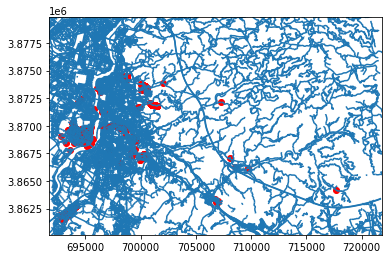

In [76]:
ax = roads.plot()
gdf.plot(ax=ax,color="red")
ax.set_xlim(691739, 721806)
ax.set_ylim(3860133, 3879810)


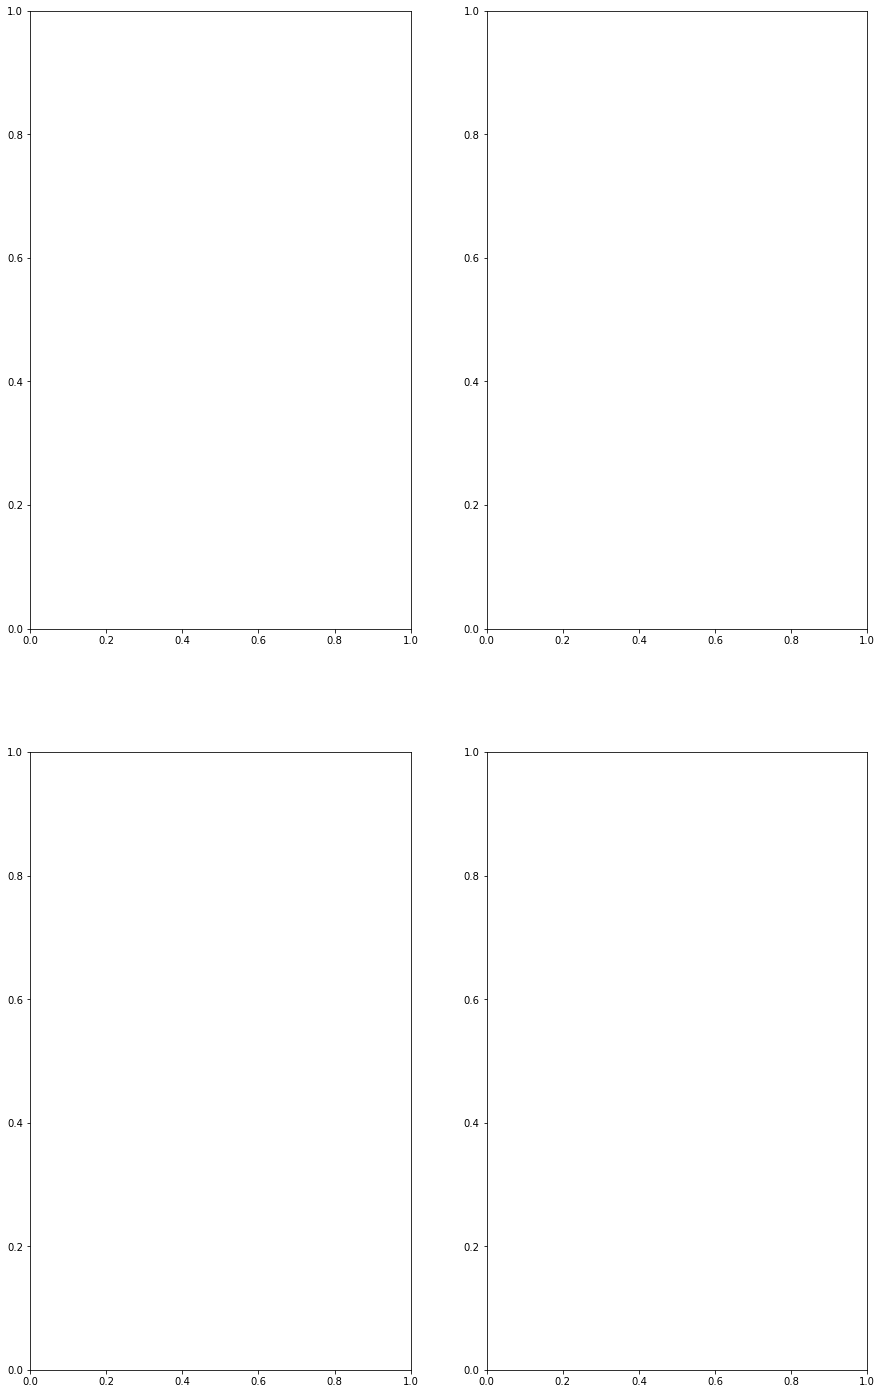

In [98]:
successfulEvacuees = {}
shelteringAtHome = {}
trapped = {}
incomplete = {}

# a map for each
# journey distribution time

xcolname = 'x_loc'
ycolname = 'y_loc'



# shelter demand, capacity over time
fig = plt.figure(figsize=(15,25))

totalSize = (2, 2)
    
ax1 = plt.subplot2grid(totalSize, (0, 0))
ax2 = plt.subplot2grid(totalSize, (0, 1))
ax3 = plt.subplot2grid(totalSize, (1, 0))
ax4 = plt.subplot2grid(totalSize, (1, 1))

axes = [ax1, ax2, ax3, ax4]
colors = ['red', 'green', 'blue', 'cyan']
index = 0

# extract them
for f in files:
    
    if f.startswith("."):
        continue    
    elif not "SHELTERS" in f:
        continue
        
    scenario = f[:f.rfind("_")]
    
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t', header=None)) # read in file


In [104]:
raw_data
raw_data['info'] = raw_data[1]

In [106]:
import ast

In [110]:
raw_data[1]

0     [0, 0, 0, 3, 10, 14, 24, 49, 73, 124, 183, 216...
1     [0, 0, 0, 0, 0, 0, 0, 7, 11, 16, 19, 31, 49, 5...
2     [0, 0, 0, 1, 2, 6, 8, 24, 38, 46, 56, 72, 92, ...
3     [0, 0, 0, 1, 8, 30, 57, 93, 142, 229, 300, 300...
4     [0, 0, 0, 0, 4, 6, 20, 48, 129, 254, 300, 300,...
                            ...                        
73    [0, 0, 0, 0, 1, 3, 16, 81, 123, 138, 150, 161,...
74    [0, 0, 0, 0, 0, 5, 16, 36, 55, 100, 144, 206, ...
75    [0, 0, 0, 0, 0, 5, 10, 88, 161, 204, 250, 300,...
76    [0, 0, 0, 3, 3, 8, 19, 62, 98, 131, 161, 215, ...
77    [0, 0, 0, 0, 0, 2, 4, 16, 52, 107, 145, 162, 1...
Name: 1, Length: 78, dtype: object